# 01 - Multi-Dataset Exploration and Split Audit

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

KAGGLE = Path("/kaggle").exists()
REPO_URL = "https://github.com/Tommyhuy1705/Explainable_NeuroSymbolic_Fraud_Detection.git"
KAGGLE_PROJECT_DIR = Path("/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection")

if KAGGLE:
    os.environ["THESIS_QUICK_RUN"] = "0"
    os.environ["THESIS_SYNTHETIC_FALLBACK"] = "0"
    if not KAGGLE_PROJECT_DIR.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", "main", REPO_URL, str(KAGGLE_PROJECT_DIR)],
            check=True,
        )

def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    for base in (Path("/kaggle/working"), Path("/kaggle/input")):
        if base.exists():
            matches = [path for path in base.glob("**/configs") if path.is_dir()]
            if matches:
                return matches[0].parent
    raise FileNotFoundError("Project root with src/ and configs/ was not found")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

QUICK_RUN = os.getenv("THESIS_QUICK_RUN", "0") == "1"
ALLOW_SYNTHETIC_FALLBACK = os.getenv("THESIS_SYNTHETIC_FALLBACK", "0") == "1"
OUTPUT_BASE = Path("/kaggle/working/thesis_outputs") if KAGGLE else PROJECT_ROOT / "results/runs/notebooks"
INPUT_ROOTS = [OUTPUT_BASE, PROJECT_ROOT / "results/runs/notebooks"]
if Path("/kaggle/input").exists():
    INPUT_ROOTS.append(Path("/kaggle/input"))

try:
    GIT_COMMIT = subprocess.check_output(
        ["git", "-C", str(PROJECT_ROOT), "rev-parse", "HEAD"], text=True
    ).strip()
except (OSError, subprocess.CalledProcessError):
    GIT_COMMIT = None

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
print({
    "project_root": str(PROJECT_ROOT),
    "git_commit": GIT_COMMIT,
    "quick_run": QUICK_RUN,
    "synthetic_fallback": ALLOW_SYNTHETIC_FALLBACK,
    "kaggle": KAGGLE,
})

Cloning into '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection'...


{'project_root': '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection', 'git_commit': '566ababab465ca98eaf6c27648993995f5553ce0', 'quick_run': False, 'synthetic_fallback': False, 'kaggle': True}


## Thiết lập

Notebook kiểm tra dữ liệu, class imbalance, missingness và ranh giới thời gian trước khi huấn luyện.
BAF phải có các nhóm tháng không giao nhau; raw time chỉ dùng để chia tập, không làm predictor feature.

In [2]:
from src.data import (
    load_config, load_fraud_dataframe, make_synthetic_baf_data,
    make_synthetic_fraud_data, prepare_dataset, split_integrity_summary,
)

max_rows = 12000 if QUICK_RUN else None
output_dir = OUTPUT_BASE / "01_data_exploration"
output_dir.mkdir(parents=True, exist_ok=True)
dataset_summaries = []

## I. IEEE-CIS

In [3]:
config = load_config(PROJECT_ROOT / "configs/ieee_cis.yaml")
try:
    frame = load_fraud_dataframe(config, max_rows=max_rows)
    data_source = "dataset_file"
except FileNotFoundError:
    if not ALLOW_SYNTHETIC_FALLBACK:
        raise
    frame = make_synthetic_fraud_data(max_rows or 6000, seed=config["project"]["seed"])
    data_source = "synthetic_fallback"
target = config["dataset"]["target_column"]
time_column = config["dataset"]["time_column"]
prepared = prepare_dataset(frame, config)
integrity = split_integrity_summary(
    prepared.train_frame, prepared.validation_frame, prepared.test_frame, time_column
)
integrity["fraud_rate"] = [prepared.y_train.mean(), prepared.y_validation.mean(), prepared.y_test.mean()]
if config["split"]["strategy"] == "temporal_group":
    assert integrity["group_disjoint"].all(), "Temporal groups overlap across BAF splits"
assert time_column not in prepared.feature_names, "Raw split time must not enter the predictor"
summary = pd.DataFrame({
    "dataset": [config["dataset"]["name"]],
    "rows": [len(frame)],
    "columns": [frame.shape[1]],
    "fraud_count": [int(frame[target].sum())],
    "fraud_rate": [float(frame[target].mean())],
    "duplicate_rows": [int(frame.duplicated().sum())],
    "data_source": [data_source],
    "selected_features": [len(prepared.feature_names)],
})
missing = frame.isna().mean().sort_values(ascending=False).rename("missing_fraction").to_frame()
dataset_summaries.append(summary)
display(summary, integrity, missing.head(20))
integrity.to_csv(output_dir / "ieee_cis_split_summary.csv", index=False)
missing.to_csv(output_dir / "ieee_cis_missingness.csv")

,dataset,rows,columns,fraud_count,fraud_rate,duplicate_rows,data_source,selected_features
0,ieee_cis,590540,437,20663,0.03499,0,dataset_file,120


,split,rows,time_min,time_max,time_group_count,time_groups,overlap_groups,group_disjoint,fraud_rate
0,train,413378,86400,10437996,400309,[],[],True,0.035169
1,validation,88581,10438003,13151840,86545,[],[],True,0.034341
2,test,88581,13151880,15811131,86495,[],[],True,0.034804


,missing_fraction
id_24,0.991962
id_25,0.991310
id_08,0.991271
id_07,0.991271
id_21,0.991264
id_26,0.991257
id_22,0.991247
id_27,0.991247
id_23,0.991247
dist2,0.936284


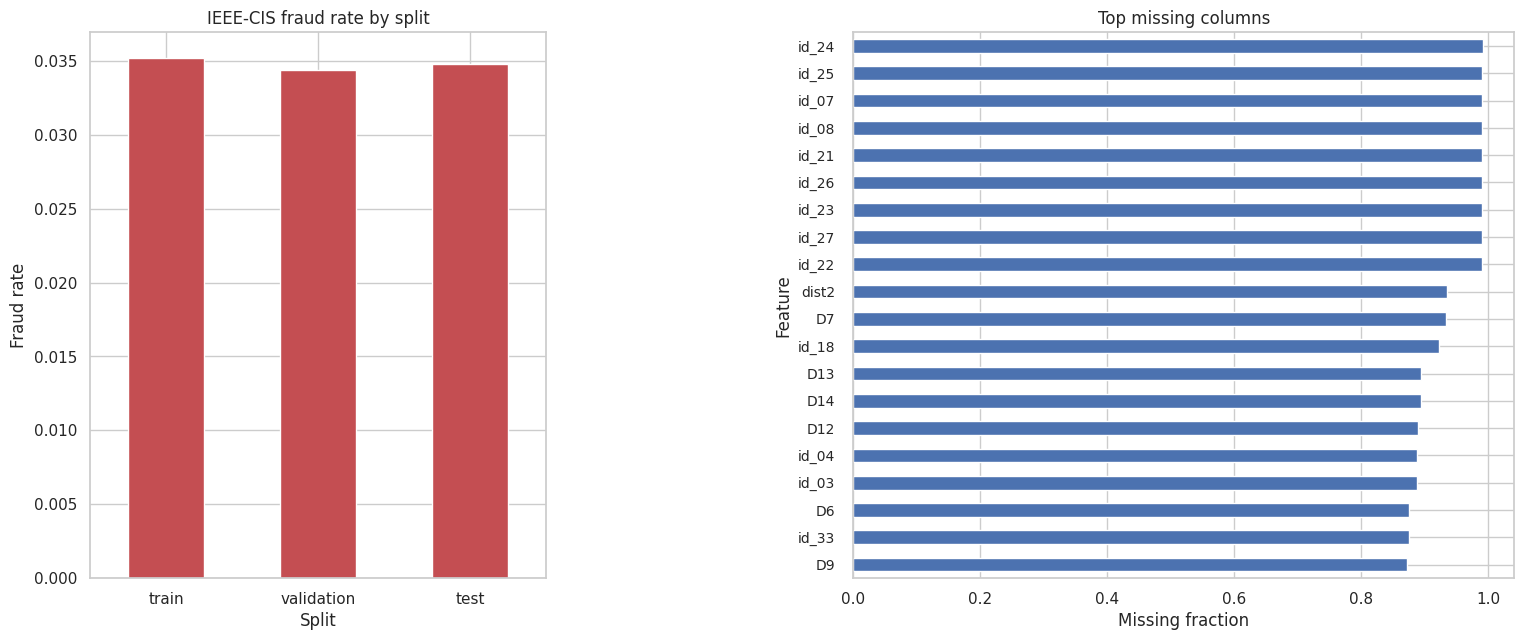

In [4]:
top_missing = missing.loc[missing["missing_fraction"] > 0].head(20).sort_values("missing_fraction")
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7),
    gridspec_kw={"width_ratios": [1.0, 1.45]},
)
integrity.plot.bar(
    x="split", y="fraud_rate", ax=axes[0], legend=False, color="#C44E52", rot=0
)
axes[0].set_title("IEEE-CIS fraud rate by split")
axes[0].set_ylabel("Fraud rate")
axes[0].set_xlabel("Split")
axes[0].margins(x=0.12)

if top_missing.empty:
    axes[1].set_title("Missingness audit")
    axes[1].text(
        0.5,
        0.5,
        "No missing values detected",
        ha="center",
        va="center",
        fontsize=13,
        color="#4C72B0",
        transform=axes[1].transAxes,
    )
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    for spine in axes[1].spines.values():
        spine.set_visible(False)
else:
    top_missing.plot.barh(ax=axes[1], legend=False, color="#4C72B0")
    axes[1].set_title("Top missing columns")
    axes[1].set_xlabel("Missing fraction")
    axes[1].set_ylabel("Feature")
    axes[1].tick_params(axis="y", labelsize=10, pad=7)
    axes[1].margins(y=0.03)

fig.subplots_adjust(left=0.08, right=0.97, bottom=0.12, top=0.90, wspace=0.55)
fig.savefig(output_dir / "ieee_cis_data_quality.png", dpi=160, bbox_inches="tight")
plt.show()

## II. BAF

In [5]:
config = load_config(PROJECT_ROOT / "configs/baf.yaml")
try:
    frame = load_fraud_dataframe(config, max_rows=max_rows)
    data_source = "dataset_file"
except FileNotFoundError:
    if not ALLOW_SYNTHETIC_FALLBACK:
        raise
    frame = make_synthetic_baf_data(max_rows or 6000, seed=config["project"]["seed"])
    data_source = "synthetic_fallback"
target = config["dataset"]["target_column"]
time_column = config["dataset"]["time_column"]
prepared = prepare_dataset(frame, config)
integrity = split_integrity_summary(
    prepared.train_frame, prepared.validation_frame, prepared.test_frame, time_column
)
integrity["fraud_rate"] = [prepared.y_train.mean(), prepared.y_validation.mean(), prepared.y_test.mean()]
if config["split"]["strategy"] == "temporal_group":
    assert integrity["group_disjoint"].all(), "Temporal groups overlap across BAF splits"
assert time_column not in prepared.feature_names, "Raw split time must not enter the predictor"
summary = pd.DataFrame({
    "dataset": [config["dataset"]["name"]],
    "rows": [len(frame)],
    "columns": [frame.shape[1]],
    "fraud_count": [int(frame[target].sum())],
    "fraud_rate": [float(frame[target].mean())],
    "duplicate_rows": [int(frame.duplicated().sum())],
    "data_source": [data_source],
    "selected_features": [len(prepared.feature_names)],
})
missing = frame.isna().mean().sort_values(ascending=False).rename("missing_fraction").to_frame()
dataset_summaries.append(summary)
display(summary, integrity, missing.head(20))
integrity.to_csv(output_dir / "baf_split_summary.csv", index=False)
missing.to_csv(output_dir / "baf_missingness.csv")

,dataset,rows,columns,fraud_count,fraud_rate,duplicate_rows,data_source,selected_features
0,baf,1000000,32,11029,0.011029,0,dataset_file,29


,split,rows,time_min,time_max,time_group_count,time_groups,overlap_groups,group_disjoint,fraud_rate
0,train,675666,0,4,5,"[0, 1, 2, 3, 4]",[],True,0.009975
1,validation,119323,5,5,1,[5],[],True,0.011825
2,test,205011,6,7,2,"[6, 7]",[],True,0.014038


,missing_fraction
fraud_bool,0.0
income,0.0
name_email_similarity,0.0
prev_address_months_count,0.0
current_address_months_count,0.0
customer_age,0.0
days_since_request,0.0
intended_balcon_amount,0.0
payment_type,0.0
zip_count_4w,0.0


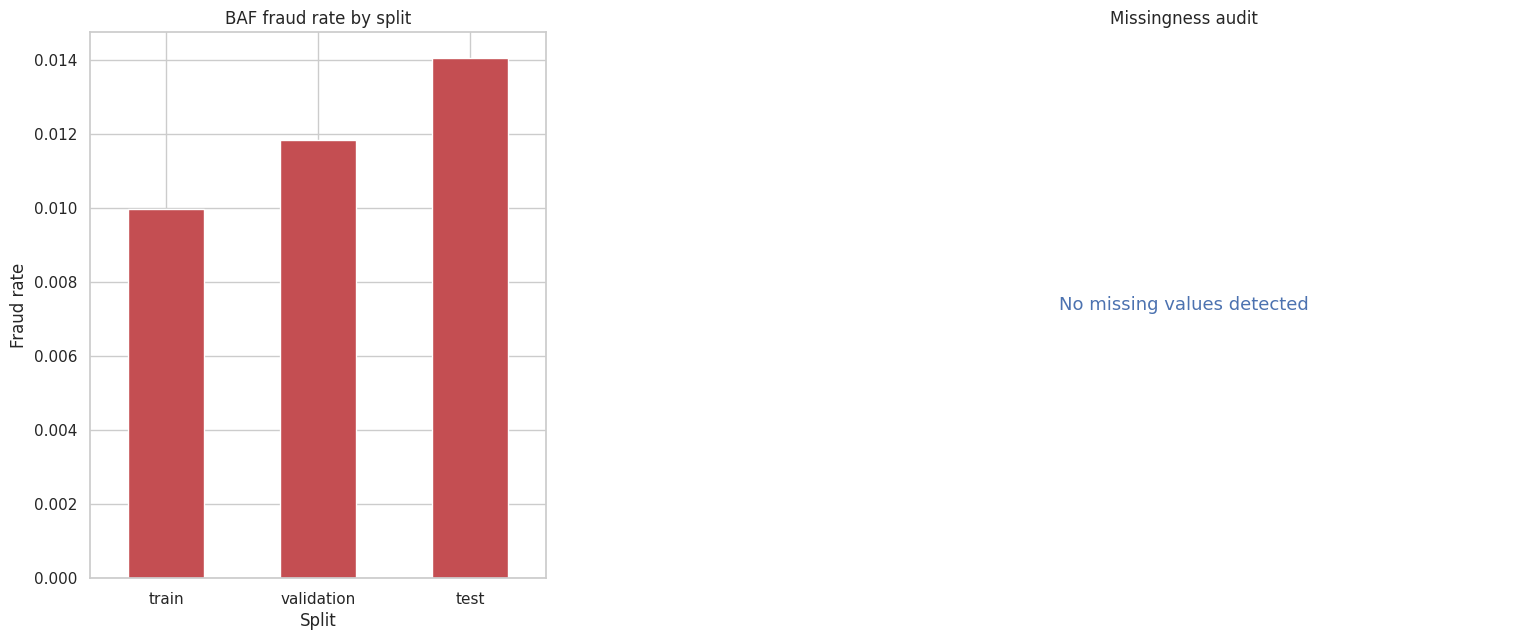

In [6]:
top_missing = missing.loc[missing["missing_fraction"] > 0].head(20).sort_values("missing_fraction")
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7),
    gridspec_kw={"width_ratios": [1.0, 1.45]},
)
integrity.plot.bar(
    x="split", y="fraud_rate", ax=axes[0], legend=False, color="#C44E52", rot=0
)
axes[0].set_title("BAF fraud rate by split")
axes[0].set_ylabel("Fraud rate")
axes[0].set_xlabel("Split")
axes[0].margins(x=0.12)

if top_missing.empty:
    axes[1].set_title("Missingness audit")
    axes[1].text(
        0.5,
        0.5,
        "No missing values detected",
        ha="center",
        va="center",
        fontsize=13,
        color="#4C72B0",
        transform=axes[1].transAxes,
    )
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    for spine in axes[1].spines.values():
        spine.set_visible(False)
else:
    top_missing.plot.barh(ax=axes[1], legend=False, color="#4C72B0")
    axes[1].set_title("Top missing columns")
    axes[1].set_xlabel("Missing fraction")
    axes[1].set_ylabel("Feature")
    axes[1].tick_params(axis="y", labelsize=10, pad=7)
    axes[1].margins(y=0.03)

fig.subplots_adjust(left=0.08, right=0.97, bottom=0.12, top=0.90, wspace=0.55)
fig.savefig(output_dir / "baf_data_quality.png", dpi=160, bbox_inches="tight")
plt.show()

## III. So sánh tổng quan

,dataset,rows,columns,fraud_count,fraud_rate,duplicate_rows,data_source,selected_features
0,ieee_cis,590540,437,20663,0.034990,0,dataset_file,120
1,baf,1000000,32,11029,0.011029,0,dataset_file,29


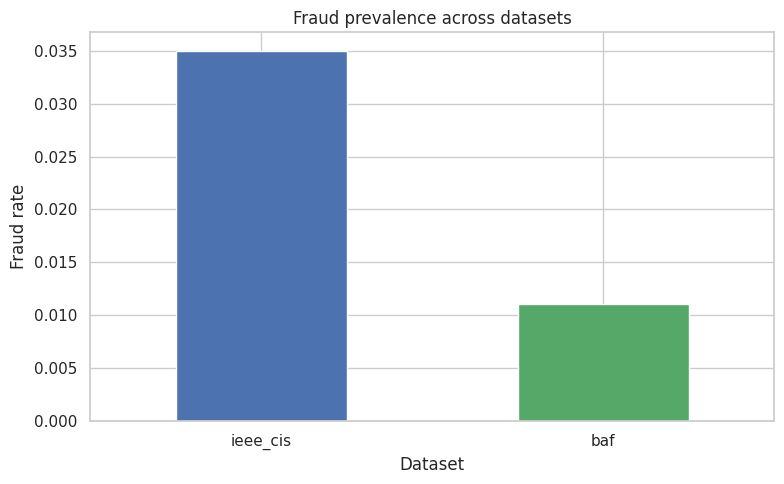

In [7]:
combined_summary = pd.concat(dataset_summaries, ignore_index=True)
display(combined_summary)
combined_summary.to_csv(output_dir / "dataset_summary.csv", index=False)
ax = combined_summary.plot.bar(
    x="dataset",
    y="fraud_rate",
    legend=False,
    color=["#4C72B0", "#55A868"],
    figsize=(8, 5),
    rot=0,
)
ax.set_title("Fraud prevalence across datasets")
ax.set_ylabel("Fraud rate")
ax.set_xlabel("Dataset")
ax.margins(x=0.15)
plt.tight_layout()
plt.savefig(output_dir / "dataset_fraud_rate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## Takeaways

In [8]:
display(Markdown(
    "- Review every displayed split before model training.\n"
    "- For BAF, the required final split is months **0-4 / 5 / 6-7** with no overlap.\n"
    "- `dataset_file` means the published benchmark file was loaded; BAF itself remains a privacy-preserving synthetic benchmark."
))

- Review every displayed split before model training.
- For BAF, the required final split is months **0-4 / 5 / 6-7** with no overlap.
- `dataset_file` means the published benchmark file was loaded; BAF itself remains a privacy-preserving synthetic benchmark.